In [11]:
import numpy as np
import os, time, datetime
from  sklearn.model_selection import train_test_split
import math
import tensorflow as tf
import os, time, numpy as np
from CNN_run_CWALDP import create_cluster,create_L_domain,grr_array
from evaluate_CWALDP_model import plot_learning_curves


In [ ]:
import tensorflow as tf

def get_model(model_name, input_shape):
    # 全モデル共通の全結合層部分を定義しておくと、コピペミスが防げます
    def common_dense_layers():
        return [
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(64),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(10, activation='softmax')
        ]

    if model_name == "model2":
        # --- ベースライン (独自構成) ---
        # Conv -> ReLU -> BN -> Dropout
        model = tf.keras.models.Sequential([
            # 第1ブロック
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
            tf.keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
            tf.keras.layers.Dropout(0.5),
            # 第2ブロック
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
            tf.keras.layers.BatchNormalization(momentum=0.99, epsilon=0.001),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Dropout(0.5),
            *common_dense_layers() # 共通部分を展開
        ])

    elif model_name == "model1":
        # --- 柳下さん (業界標準構成) ---
        # Conv -> BN -> ReLU -> Pooling (Dropoutなし)
        model = tf.keras.models.Sequential([
            # 第1ブロック
            tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', input_shape=input_shape),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
            # 第2ブロック
            tf.keras.layers.Conv2D(64, kernel_size=3, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
            *common_dense_layers()
        ])

    elif model_name == "model3":
        # --- Model 2 改 (No Dropout) ---
        # Conv層のDropoutを削除して、BNとの相性を見る
        model = tf.keras.models.Sequential([
            # 第1ブロック
            tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', input_shape=input_shape),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.BatchNormalization(),
            # Dropoutなし
            # 第2ブロック
            tf.keras.layers.Conv2D(64, kernel_size=3, padding='same'),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.BatchNormalization(),
            # Dropoutなし
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
            *common_dense_layers()
        ])

    elif model_name == "model4":
        # --- Model 2 改 (Standard Order) ---
        # BNと活性化関数の順序を標準(BN->ReLU)にする
        model = tf.keras.models.Sequential([
            # 第1ブロック
            tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', input_shape=input_shape),
            tf.keras.layers.BatchNormalization(), # 先
            tf.keras.layers.Activation('relu'),   # 後
            tf.keras.layers.Dropout(0.25),
            # 第2ブロック
            tf.keras.layers.Conv2D(64, kernel_size=3, padding='same'),
            tf.keras.layers.BatchNormalization(), # 先
            tf.keras.layers.Activation('relu'),   # 後
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
            *common_dense_layers()
        ])

    elif model_name == "model5": # ★ここ修正しました
        # --- Model 2 改 (High Pooling) ---
        # Poolingを柳下さんに合わせて増やし、パラメータ数を減らす
        model = tf.keras.models.Sequential([
            # 第1ブロック
            tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', input_shape=input_shape),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2), # 追加
            # 第2ブロック
            tf.keras.layers.Conv2D(64, kernel_size=3, padding='same'),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
            *common_dense_layers()
        ])
    elif model_name == "model6":
        # --- Model 6 (1層のみ) ---
        # 入力が14x14なので、1回Poolingして7x7にするのがベストバランスと予想
        model = tf.keras.models.Sequential([
            # --- 第1畳み込み層ブロック ---
            tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', input_shape=(14, 14, 1)), # サイズ明示
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
            tf.keras.layers.Dropout(0.25),
            
            # 14x14 -> 7x7 にダウンサンプリング
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),

            # --- 全結合層 (共通) ---
            # ここで 7x7x32 のデータが平坦化されます
            *common_dense_layers()
        ])
    elif model_name == "model7":
        # --- Model 2 改 (Standard Order) ---
        # BNと活性化関数の順序を標準(BN->ReLU)にする
        model = tf.keras.models.Sequential([
            # 第1ブロック
            tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', input_shape=input_shape),
            tf.keras.layers.BatchNormalization(), # 先
            tf.keras.layers.Activation('relu'),   # 後
            # 第2ブロック
            tf.keras.layers.Conv2D(64, kernel_size=3, padding='same'),
            tf.keras.layers.BatchNormalization(), # 先
            tf.keras.layers.Activation('relu'),   # 後
            tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
            *common_dense_layers()
        ])
            
    else:
        raise ValueError(f"Unknown model name: {model_name}")
    
    return model

Successfully configured GPU: /physical_device:GPU:0
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5969 - loss: 1.1724 - val_accuracy: 0.8107 - val_loss: 0.5214 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7937 - loss: 0.5619 - val_accuracy: 0.8403 - val_loss: 0.4454 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8219 - loss: 0.4939 - val_accuracy: 0.8491 - val_loss: 0.4229 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8282 - loss: 0.4614 - val_accuracy: 0.8533 - val_loss: 0.4007 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8402 - loss: 0.4462 - val_accuracy: 0.8642 - val_loss: 0.3787 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8485 - loss: 0.4116 - val_accuracy: 0.8624 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━

=== model6 Final Metrics ===
Loss     | Train: 0.2790, Val: 0.3455, Test: 0.3480,Test_noise: 0.3480
Accuracy | Train: 0.8964, Val: 0.8713, Test: 0.8731,Test_noise: 0.8731


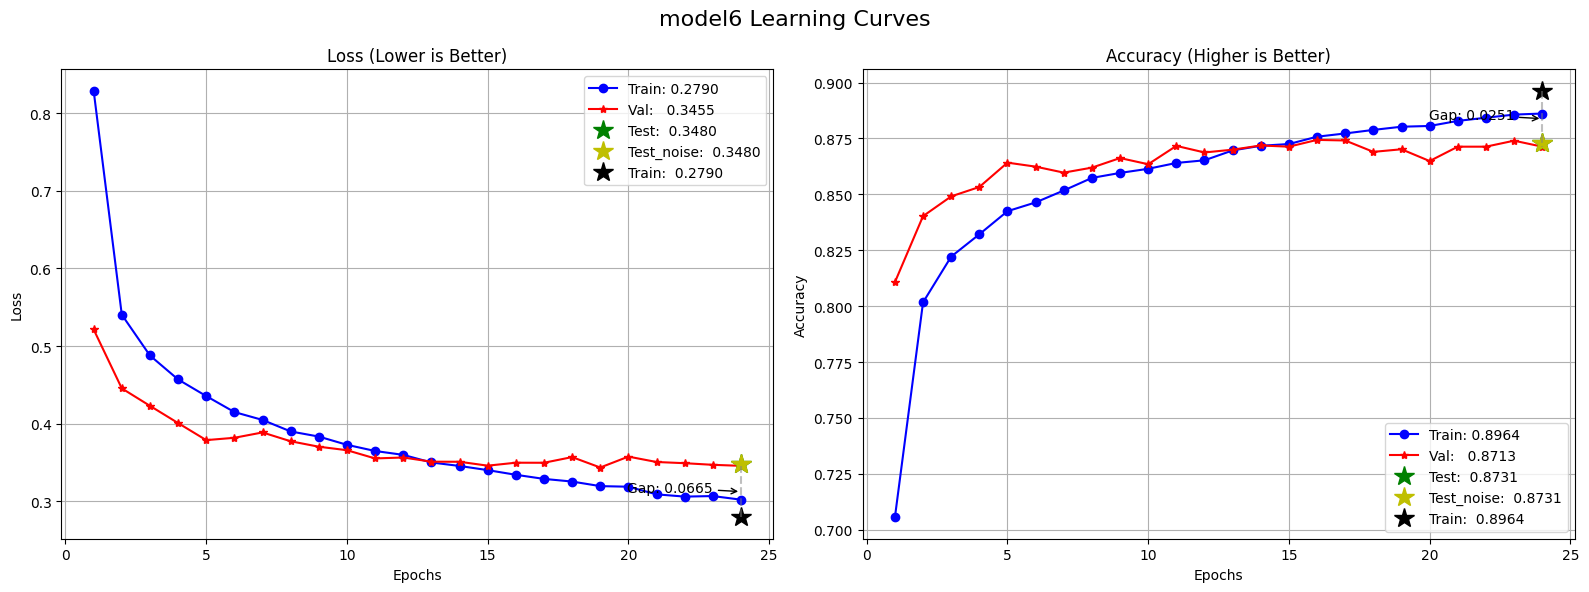

In [ ]:

# --- モデルサマリーを取得するヘルパー関数 (新規追加) ---

def train_model(X_train_noise,X_test_noise,X_test,y_train_reshaped,y_test,input_shape,model,model_name):

        X_train_noise_reshaped = X_train_noise.reshape(-1, *input_shape)

        X_test_noise_reshaped = X_test_noise.reshape(-1, *input_shape)

        X_test_reshaped=X_test.reshape(-1,*input_shape)

        # --------------------------
        # コンパイル
        # --------------------------
        model.compile( optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"] )
        # -------------------------- # コールバック設定 # -------------------------- 
    # --------------------------
        # コールバック設定 (修正箇所)
        # --------------------------
        # 1. EarlyStopping
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
        
        # 2. LearningRateScheduler
        def scheduler(epoch, lr):
            if epoch > 50: return lr * 0.5
            return lr
        lr_schedule = tf.keras.callbacks.LearningRateScheduler(scheduler)

        # 3. TensorBoard設定 (★ここを追加)
        # ログ名を「日時_モデル名」にすることで、TensorBoard上で比較しやすくする
        log_name = f"{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}_{model_name}_L{L}_PI{PI}_C{cluster_num}"
        log_dir = "../../logs/fit/" + log_name
        tensorboard_callback = tf.keras.callbacks.TensorBoard(
            log_dir=log_dir, 
            histogram_freq=1 # 各層の重みの分布も記録する
        )

        # --------------------------
        # 学習
        # --------------------------
        history = model.fit(
            X_train_noise_reshaped, y_train_reshaped,
            validation_split=0.2,
            epochs=50,
            batch_size=256,
            # ★ callbacksリストに tensorboard_callback と early_stop を追加
            callbacks=[lr_schedule, early_stop, tensorboard_callback], 
            verbose=1
        )

        # --------------------------
        # サマリー取得
        # --------------------------
        stringlist = []
        model.summary(print_fn=lambda x, **kwargs: stringlist.append(x))
        model_summary = "\n".join(stringlist)

        # --------------------------
        # テスト評価
        # --------------------------
        test_noise_loss, test_noise_acc = model.evaluate(X_test_noise_reshaped, y_test, verbose=0)
        test_loss, test_acc = model.evaluate(X_test_reshaped, y_test, verbose=0)
        train_loss, train_acc = model.evaluate(X_train_noise_reshaped, y_train_reshaped, verbose=0)

        return test_loss, test_acc, test_noise_loss, test_noise_acc, train_loss, train_acc, model_summary, history
            



def waldp_time(original_path, output_path, epsilon_per_pixel, PI, L,cluster_num, seed,label_epsilon,model_name):
    """
    Measure training/inference time of RandomForest on GRR-perturbed WA datasets.

    Output CSV columns:
        P,L,epsilon,seed,fold,test_env,time_sec,accuracy
    """
         
    # --- GPU 設定の追加 ---
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # メモリ成長を有効にする（必要なメモリだけを割り当てる）
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            # 最初のGPUデバイスを使用
            tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
            print(f"Successfully configured GPU: {gpus[0].name}")
        except RuntimeError as e:
            # 設定がデバイスの初期化後に呼び出された場合に発生
            print(f"GPU configuration failed: {e}")
    else:
        print("No GPU devices found. Running on CPU.")
        
        

    dat = np.load(original_path, allow_pickle=True)
    X_all = np.asarray(dat["X_disc"])
    y_all = np.asarray(dat["y_disc"] if "y_disc" in dat.files else dat["y_all"])

    if y_all.ndim > 1:
        y_all = y_all.reshape(-1)

    assert X_all.shape[0] == y_all.shape[0], "X と y の件数が一致しません"
    #画素数の計算
    pixel=int(X_all.shape[1])
    epsilon=pixel*epsilon_per_pixel



    # tone reduction domain (整数リスト)
    # get the domain of tones.
    L_values = create_L_domain(L)
    
    if PI!=1:
        clusters = create_cluster(pixel, cluster_num)
    else:
        clusters=[]
    epsilon_for_onecluster = epsilon/(cluster_num-1) #ラベルノイズを無視しているため、クラスターが一つ減る。

    X_train,X_test,y_train,y_test=train_test_split(X_all,y_all,test_size=0.2,random_state=42)

    # ---- Train noise ----
    X_train_noise = X_train.copy()
    for cluster in clusters:
            epsilon_for_onepixel = epsilon_for_onecluster/len(cluster)
            for j in cluster:
                X_train_noise[:, j] = grr_array(X_train[:, j], epsilon_for_onepixel, L_values, seed + 10007 * j)

    label_domain = list(range(10))
    #ラベルのノイズ
    y_train_noise = grr_array(y_train, label_epsilon, label_domain, seed)


    X_test_noise = X_test.copy()
    for cluster in clusters:
        epsilon_for_onepixel = epsilon_for_onecluster/len(cluster)
        for j in cluster:
            X_test_noise[:, j] = grr_array(X_test[:, j],epsilon_for_onepixel, L_values, seed + 20011 * j)

    # データの全長 (BFの長さ) を取得
    edge_size=int(math.sqrt(X_train_noise.shape[1]))
    H, W = edge_size,edge_size
    C = 1 # チャンネル数 (BFはグレースケールとして扱うため 1)
    input_shape = (H, W, C)
    
    model=get_model(model_name,input_shape)
    
    test_loss,test_acc,test_noise_loss, test_noise_acc,train_loss,train_acc,current_summary,history =train_model(X_train_noise,X_test_noise,X_test,y_train_noise,y_test,input_shape,model,model_name)
    plot_learning_curves(history,test_loss,test_acc,test_noise_loss, test_noise_acc,train_loss,train_acc,output_path, model_name)
        # waldp_time またはループの最後
    tf.keras.backend.clear_session()
    import gc
    gc.collect()
    return 0



if __name__ == "__main__":
    data="FashionMNIST"
    epsilons=[0]
    params = [(0.5,4,10,0)]
    seed=1
    for model_name in ["model7"]:
        for PI, L,cluster_num,label_epsilon in params:
            for eps in epsilons:   
                if data=="FashionMNIST" :    
                 input_path = f"../../data/{data}/CWALDP/fmnist_full_L{L}_PI{PI}.npz"
                elif data=="MNIST":
                 input_path = f"../../data/{data}/CWALDP/mnist_full_L{L}_PI{PI}.npz"
                # 現在日時を取得し、YYYYMMDD-HHMMSS形式の文字列を生成
                timestamp = datetime.datetime.now().strftime("%Y%m%d")
                output_path = f"../../experiments/{data}/CWALDP/CNN/{timestamp}/RR_waldp_L{L}_PI{PI}_C{cluster_num}_eps{eps}_label_noise_{label_epsilon}_{model_name}_seed{seed}.png"
                os.makedirs(os.path.dirname(output_path), exist_ok=True)
                waldp_time(input_path, output_path, eps, PI, L,cluster_num,seed,label_epsilon,model_name)

In [13]:
H, W = 14,14
C = 1 # チャンネル数 (BFはグレースケールとして扱うため 1)
input_shape = (H, W, C)
for model_name in ["model1","model2","model3","model4","model5"]:
    model=get_model(model_name, input_shape)
    model.save(f'../../model_info/{model_name}.h5')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(
